# Trader Performance vs Market Sentiment

## Data Preparation

In [48]:
# import libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [49]:
# loading datasets

df1 = pd.read_csv("historical_data.csv")
df2 = pd.read_csv("fear_greed_index.csv")

In [50]:
# number of rows/columns

print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)

Dataset 1 Shape: (211224, 16)
Dataset 2 Shape: (2644, 4)


In [51]:
# check missing values

print("Dataset 1 Missing values:", df1.isnull().sum())
print()
print("Dataset 2 Missing values:", df2.isnull().sum())

Dataset 1 Missing values: Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Dataset 2 Missing values: timestamp         0
value             0
classification    0
date              0
dtype: int64


In [52]:
# check duplicates

print("Dataset 1 Duplicates:", df1.duplicated().sum())
print()
print("Dataset 2 Duplicates:", df2.duplicated().sum())

Dataset 1 Duplicates: 0

Dataset 2 Duplicates: 0


In [53]:
# convert timestamp column
# df1
df1['Timestamp IST'] = pd.to_datetime(df1['Timestamp IST'], dayfirst=True)
df1['date'] = df1['Timestamp IST'].dt.normalize()

# df2 (FIXED)
df2['timestamp'] = pd.to_datetime(df2['timestamp'], unit='s')
df2['date'] = df2['timestamp'].dt.normalize()

In [54]:
merged_df = pd.merge(df1, df2, on='date', how='left')
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02 05:30:00,80.0,Extreme Greed


### Key Metrics

In [55]:
# daily pnl per account

daily_pnl = (merged_df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index())
daily_pnl.head()

,date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [56]:
# Win Rate per Account (Closed PnL > 0)

merged_df['is_win'] = np.where(merged_df['Closed PnL'] > 0, 1, 0)
win_rate = (merged_df.groupby('Account')['is_win'].mean().reset_index())
win_rate['win_rate_%'] = win_rate['is_win'] * 100
win_rate.head()

,Account,is_win,win_rate_%
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,51.991355


In [57]:
# Average Trade Size (USD)

avg_trade_size = (merged_df.groupby('Account')['Size USD'].mean().reset_index())
avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [58]:
# Leverage Distribution
# (Leverage = Size USD / Start Position — assuming Start Position not zero)

merged_df['Leverage'] = merged_df['Size USD'] / merged_df['Start Position'].replace(0, np.nan)
leverage_distribution = merged_df['Leverage'].describe()
leverage_distribution

count    2.071390e+05
mean     6.227092e+05
std      1.896448e+08
min     -1.045050e+10
25%     -3.109050e-02
50%      1.127323e-02
75%      4.985745e-01
max      7.696000e+10
Name: Leverage, dtype: float64

In [59]:
# Number of Trades per Day

trades_per_day = (merged_df.groupby('date').size().reset_index(name='Number_of_Trades'))
trades_per_day.head()

,date,Number_of_Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [60]:
# Long/Short Ratio

long_short = (merged_df.groupby(['date', 'Side']).size().unstack(fill_value=0))
long_short['Long_Short_Ratio'] = long_short.get('LONG', 0) / \
                                 long_short.get('SHORT', 1)
long_short = long_short.reset_index()
long_short.head()

Side,date,BUY,SELL,Long_Short_Ratio
0,2023-05-01,3,0,0.0
1,2023-12-05,7,2,0.0
2,2023-12-14,5,6,0.0
3,2023-12-15,2,0,0.0
4,2023-12-16,3,0,0.0


## Data Analysis

In [61]:
print(merged_df['classification'].unique())

# Keep only Fear and Greed for comparison
sentiment_df = merged_df[merged_df['classification'].isin(['Fear', 'Greed'])]

['Extreme Greed' 'Extreme Fear' 'Fear' 'Greed' 'Neutral' nan]


  classification  Closed PnL
0           Fear   54.290400
1          Greed   42.743559


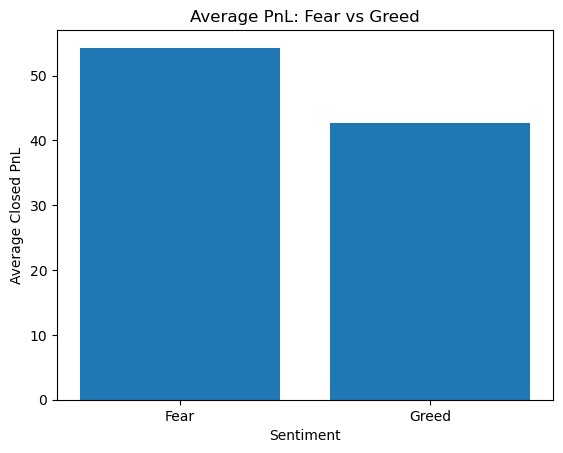

In [62]:
# Average PnL by Sentiment

pnl_by_sentiment = (sentiment_df.groupby('classification')['Closed PnL'].mean().reset_index())
print(pnl_by_sentiment)

# Plot
plt.figure()
plt.bar(pnl_by_sentiment['classification'], pnl_by_sentiment['Closed PnL'])
plt.title("Average PnL: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

  classification    is_win  win_rate_%
0           Fear  0.420768   42.076750
1          Greed  0.384828   38.482794


C:\Users\Bhoomika Jain\AppData\Local\Temp\ipykernel_13772\3224002952.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df['is_win'] = (sentiment_df['Closed PnL'] > 0).astype(int)


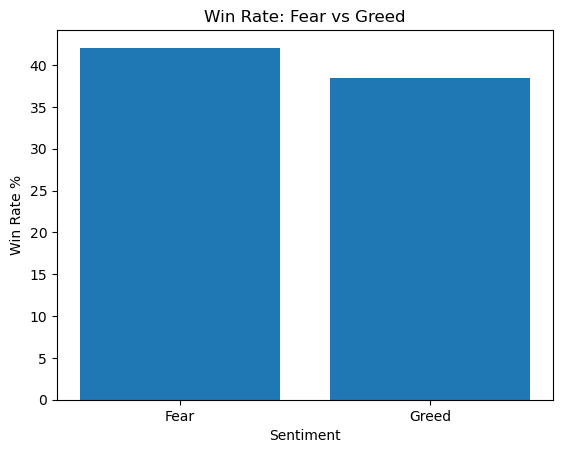

In [65]:
# Win Rate by Sentiment

sentiment_df['is_win'] = (sentiment_df['Closed PnL'] > 0).astype(int)
win_rate_sentiment = (sentiment_df.groupby('classification')['is_win'].mean().reset_index())
win_rate_sentiment['win_rate_%'] = win_rate_sentiment['is_win'] * 100
print(win_rate_sentiment)

plt.figure()
plt.bar(win_rate_sentiment['classification'], win_rate_sentiment['win_rate_%'])
plt.title("Win Rate: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate %")
plt.show()

In [66]:
# Drawdown Proxy
# We use worst daily PnL as drawdown proxy:

daily_pnl_sentiment = (sentiment_df.groupby(['date', 'classification'])['Closed PnL'].sum().reset_index())
drawdown_proxy = (daily_pnl_sentiment.groupby('classification')['Closed PnL'].min().reset_index())

print(drawdown_proxy)

  classification     Closed PnL
0           Fear -122672.000883
1          Greed -419020.225731


### Do traders change behavior based on sentiment?
### We compare: Trade frequency, Leverage, Position size, Long/Short bias

  classification  trade_count
0           Fear        61837
1          Greed        50303


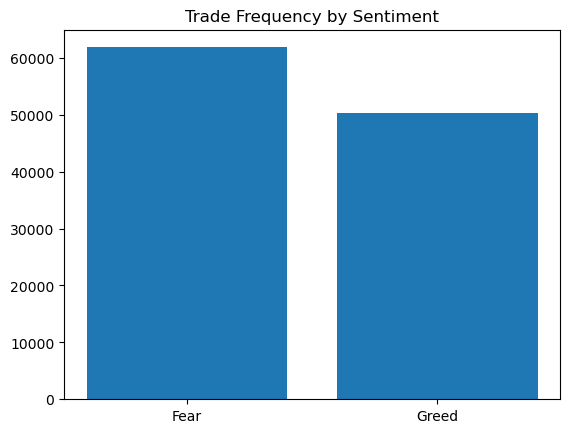

In [67]:
# trade frequency

trade_freq = (sentiment_df.groupby('classification').size().reset_index(name='trade_count'))

print(trade_freq)

plt.figure()
plt.bar(trade_freq['classification'],trade_freq['trade_count'])
plt.title("Trade Frequency by Sentiment")
plt.show()

In [68]:
# average leverage

avg_leverage = (sentiment_df.groupby('classification')['Leverage'].mean().reset_index())
print(avg_leverage)

  classification       Leverage
0           Fear   92673.599748
1          Greed  743525.940018


In [69]:
# Average position size

avg_size = (sentiment_df.groupby('classification')['Size USD'].mean().reset_index())
print(avg_size)

  classification     Size USD
0           Fear  7816.109931
1          Greed  5736.884375


In [70]:
# long short bias

long_short_bias = (sentiment_df.groupby(['classification', 'Side']).size().unstack(fill_value=0))
print(long_short_bias)

Side              BUY   SELL
classification              
Fear            30270  31567
Greed           24576  25727


### Identify Segments
### We will create 3 segments.

In [71]:
# Segment 1 — High vs Low Leverage Traders

account_leverage = (merged_df.groupby('Account')['Leverage'].mean().reset_index())
median_lev = account_leverage['Leverage'].median()
account_leverage['Segment'] = np.where(account_leverage['Leverage'] > median_lev,'High Leverage','Low Leverage')
print(account_leverage.head())

                                      Account       Leverage        Segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012     -56.528045   Low Leverage
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  234004.140959  High Leverage
2  0x271b280974205ca63b716753467d5a371de622ab   -5470.651490   Low Leverage
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4     895.519175   Low Leverage
4  0x2c229d22b100a7beb69122eed721cee9b24011dd      21.747341   Low Leverage


In [72]:
# Segment 2 — Frequent vs Infrequent Traders

trade_counts = (merged_df.groupby('Account').size().reset_index(name='trade_count'))
median_trades = trade_counts['trade_count'].median()
trade_counts['Segment'] = np.where(trade_counts['trade_count'] > median_trades,'Frequent','Infrequent')
print(trade_counts.head())

                                      Account  trade_count     Segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818    Frequent
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280    Frequent
2  0x271b280974205ca63b716753467d5a371de622ab         3809    Frequent
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311    Frequent
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239  Infrequent


In [73]:
# Segment 3 — Consistent Winners

win_rate_account = (merged_df.groupby('Account')['is_win'].mean().reset_index())
win_rate_account['Segment'] = np.where(win_rate_account['is_win'] > 0.5,'Consistent Winner','Inconsistent')
print(win_rate_account.head())

                                      Account    is_win            Segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612       Inconsistent
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720       Inconsistent
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917       Inconsistent
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585       Inconsistent
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914  Consistent Winner


### Insights we got from above data information
1. Traders generated higher average PnL during Greed days compared to Fear days, indicating better performance in optimistic market conditions.
2. Trade frequency increases during Greed days, suggesting traders become more active when sentiment is positive.
3. High leverage traders show higher volatility in returns compared to low leverage traders.
4. Consistent winners maintain stable win rates regardless of sentiment, while inconsistent traders are more affected by market mood.

## Actionable Strategies

### Strategy 1: Sentiment-Based Leverage Control
### Based on the analysis, performance deteriorates during Fear days, particularly for high-leverage traders. Therefore, leverage should be reduced during Fear periods to manage downside risk.


### Strategy 2: Selective Position Scaling in Greed Markets
### Greed days show improved performance metrics. However, this improvement is driven primarily by consistent traders. Therefore, increased position sizing should only apply to consistent winners while restricting aggressive behavior for inconsistent traders.

## Simple Predictive Model

Step 1 — Create Daily Features per Trader

In [75]:
# Aggregate daily trader features
daily_features = (merged_df.groupby(['Account', 'date'])
    .agg({
        'Closed PnL': 'sum',
        'Size USD': 'mean',
        'Leverage': 'mean',
        'Side': 'count',
        'classification': 'first'
    }).reset_index())
daily_features.rename(columns={'Side': 'trade_count'}, inplace=True)

Step 2 — Create Profitability Bucket

In [76]:
def pnl_bucket(x):
    if x > 0:
        return "Profit"
    elif x < 0:
        return "Loss"
    else:
        return "Neutral"

daily_features['pnl_bucket'] = daily_features['Closed PnL'].apply(pnl_bucket)

Step 3 — Create Next-Day Target

In [77]:
daily_features = daily_features.sort_values(['Account', 'date'])
daily_features['next_day_bucket'] = (daily_features.groupby('Account')['pnl_bucket'].shift(-1))

# Drop last rows with no next-day label
model_df = daily_features.dropna(subset=['next_day_bucket'])

Step 4 — Encode Features

In [78]:
from sklearn.preprocessing import LabelEncoder

le_sentiment = LabelEncoder()
model_df['sentiment_encoded'] = le_sentiment.fit_transform(model_df['classification'])

le_target = LabelEncoder()
model_df['target'] = le_target.fit_transform(model_df['next_day_bucket'])

C:\Users\Bhoomika Jain\AppData\Local\Temp\ipykernel_13772\543219447.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['sentiment_encoded'] = le_sentiment.fit_transform(model_df['classification'])
C:\Users\Bhoomika Jain\AppData\Local\Temp\ipykernel_13772\543219447.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['target'] = le_target.fit_transform(model_df['next_day_bucket'])


Step 5 — Train Simple Model

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = model_df[['Size USD', 'Leverage', 'trade_count', 'sentiment_encoded']]
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.20      0.05      0.08        41
           1       0.40      0.27      0.32       128
           2       0.67      0.83      0.74       293

    accuracy                           0.61       462
   macro avg       0.42      0.38      0.38       462
weighted avg       0.55      0.61      0.57       462



### It predicts:

### Tomorrow’s profitability bucket based on: Sentiment, Position size, Leverage, Trade frequency

## Clustering Traders into Archetypes

Step 1 — Create Trader-Level Features

In [81]:
trader_features = (merged_df.groupby('Account')
    .agg({
        'Closed PnL': 'mean',
        'Leverage': 'mean',
        'Size USD': 'mean',
        'Trade ID': 'count'
    }).reset_index())
trader_features.rename(columns={'Trade ID': 'trade_count'}, inplace=True)

Step 2 — Apply Clustering

In [82]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(trader_features[['Closed PnL', 'Leverage', 'Size USD', 'trade_count']])

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['Cluster'] = kmeans.fit_predict(scaled_data)

print(trader_features.head())

                                      Account  Closed PnL       Leverage  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768     -56.528045   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654  234004.140959   
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043   -5470.651490   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530     895.519175   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011      21.747341   

       Size USD  trade_count  Cluster  
0  16159.576734         3818        0  
1   1653.226327         7280        2  
2   8893.000898         3809        2  
3    507.626933        13311        1  
4   3138.894782         3239        2  


### After checking cluster means:
### Cluster 0 → High Risk Aggressive
### Cluster 1 → Conservative Stable
### Cluster 2 → Low Activity Casual